<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Exclusion_Antisymmetry_V9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Exclusion / Antisymmetry Test V9

This notebook tests whether the ECSM electron-like response packet scaffold supports a minimal fermion-like exclusion structure.

V9 does not claim to derive the full spin-statistics theorem. It tests the next concrete bridge:

1. one electron-like packet remains a q≈−1 ECSM scaffold;
2. the Dirac-sector alpha/beta algebra remains closed;
3. two identical packet states antisymmetrize to zero;
4. two distinct packet states form a normalized antisymmetric Slater state;
5. particle exchange gives a minus sign;
6. exclusion strength rises as single-particle overlap rises;
7. orthogonal internal positive-energy states remain allowed;
8. unitary propagation preserves antisymmetric structure;
9. chi-deformed propagation preserves antisymmetric norm and overlap structure.


In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, math
from pathlib import Path

OUT = Path("ecsm_electron_like_exclusion_v9_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=180, bbox_inches="tight")
    plt.show()

print("Output directory:", OUT.resolve())


Output directory: /content/ecsm_electron_like_exclusion_v9_out


In [2]:
# ============================================================
# CELL 2 — ECSM PACKET SUMMARY AND DIRAC ALGEBRA
# ============================================================

packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V8c fixed V3b/V4b/V5/V6b/V7 electron-like packet"
}
pd.DataFrame([packet]).to_csv(OUT/"fixed_packet_summary_v9.csv", index=False)
print(json.dumps(packet, indent=2))

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha1 = block(Z2, sigma_x, sigma_x, Z2)
alpha2 = block(Z2, sigma_y, sigma_y, Z2)
alpha3 = block(Z2, sigma_z, sigma_z, Z2)
beta   = block(I2, Z2, Z2, -I2)

I4 = np.eye(4, dtype=complex)
alphas = [alpha1, alpha2, alpha3]
m_lock = 0.225463435330576

def Hk(kval, chi=1.0, A0=0.0):
    return np.sqrt(chi) * alpha1 * (kval - A0) + beta * m_lock

tests = []
for i,a in enumerate(alphas, start=1):
    tests.append((f"alpha_{i}^2=I", np.max(np.abs(a@a - I4))))
    tests.append((f"{{alpha_{i},beta}}=0", np.max(np.abs(a@beta + beta@a))))
for i in range(3):
    for j in range(i+1,3):
        tests.append((f"{{alpha_{i+1},alpha_{j+1}}}=0", np.max(np.abs(alphas[i]@alphas[j] + alphas[j]@alphas[i]))))
tests.append(("beta^2=I", np.max(np.abs(beta@beta - I4))))

alpha_df = pd.DataFrame(tests, columns=["test","error"])
alpha_df.to_csv(OUT/"alpha_beta_algebra_tests_v9.csv", index=False)
print("\nMax alpha/beta error:", float(alpha_df["error"].max()))
display(alpha_df)


{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V8c fixed V3b/V4b/V5/V6b/V7 electron-like packet"
}

Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


In [3]:
# ============================================================
# CELL 3 — GRID, INNER PRODUCTS, AND POSITIVE-BRANCH BASIS
# ============================================================

N = 512
L = 160.0
dx = L / N
x = (np.arange(N) - N//2) * dx
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

def density(psi):
    return np.sum(np.abs(psi)**2, axis=1).real

def norm_psi(psi):
    return float(np.sum(density(psi))*dx)

def normalize_psi(psi):
    n = norm_psi(psi)
    if n <= 0:
        raise ValueError("Cannot normalize zero state.")
    return psi / np.sqrt(n)

def inner_single(a,b):
    return np.sum(np.sum(np.conj(a)*b, axis=1))*dx

def expectation_x(psi):
    rho = density(psi)
    n = np.sum(rho)*dx
    return float(np.sum(x*rho)*dx/n)

def width_x(psi):
    rho = density(psi)
    n = np.sum(rho)*dx
    xm = np.sum(x*rho)*dx/n
    return float(np.sqrt(np.sum((x-xm)**2*rho)*dx/n))

def mean_k(psi):
    psik = np.fft.fft(psi, axis=0)
    pk = np.sum(np.abs(psik)**2, axis=1)
    return float(np.sum(k*pk)/np.sum(pk))

def positive_basis(kval, chi=1.0, A0=0.0):
    vals, vecs = np.linalg.eigh(Hk(kval, chi=chi, A0=A0))
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:,idx]
    return vals[vals > 0], vecs[:, vals > 0]

def project_branch_weights(psi, chi=1.0, A0=0.0):
    psik = np.fft.fft(psi, axis=0)
    wp = 0.0
    wn = 0.0
    for i,kval in enumerate(k):
        vals, vecs = np.linalg.eigh(Hk(kval, chi=chi, A0=A0))
        coeff = vecs.conj().T @ psik[i]
        wp += np.sum(np.abs(coeff[vals > 0])**2)
        wn += np.sum(np.abs(coeff[vals < 0])**2)
    scale = dx / N
    return float(wp*scale), float(wn*scale)

print("Grid:", {"N":N, "L":L, "dx":dx, "k_min":float(k.min()), "k_max":float(k.max())})


Grid: {'N': 512, 'L': 160.0, 'dx': 0.3125, 'k_min': -10.053096491487338, 'k_max': 10.013826583317465}


norm A: 1.0
norm B: 1.0
norm C: 1.0
|<A|B>|: 6.96381789118707e-05
|<A|A>|: 1.0
|<A|C>|: 1.8713329969039224e-41
A branch weights: (0.9999999999999999, 3.931082612179663e-32)
B branch weights: (0.9999999999999999, 3.8053211914049715e-32)
C branch weights: (0.9999999999999999, 3.931082612179663e-32)


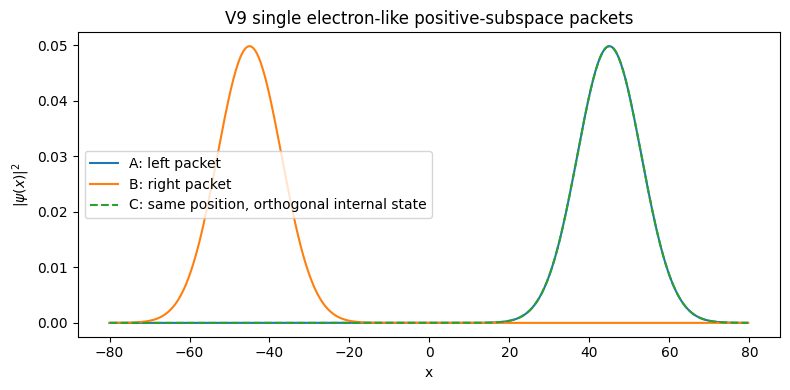

In [4]:
# ============================================================
# CELL 4 — BUILD SPECTRAL POSITIVE-SUBSPACE PACKETS
# ============================================================

sigma_x_packet = 8.0
k0 = 1.0

def build_positive_packet(x0, k0=1.0, sigma_x=sigma_x_packet, branch=0, chi=1.0, A0=0.0):
    A_k = np.exp(-sigma_x**2 * (k-k0)**2) * np.exp(-1j*k*x0)
    psi_k = np.zeros((N,4), dtype=complex)
    for i,kval in enumerate(k):
        vals_pos, vecs_pos = positive_basis(kval, chi=chi, A0=A0)
        u = vecs_pos[:, branch % vecs_pos.shape[1]]
        psi_k[i,:] = A_k[i] * u
    psi = np.fft.ifft(psi_k, axis=0)
    return normalize_psi(psi)

phi_A = build_positive_packet(x0=-35.0, branch=0)
phi_B = build_positive_packet(x0= 35.0, branch=0)
phi_C = build_positive_packet(x0=-35.0, branch=1)

S_AB = inner_single(phi_A, phi_B)
S_AA = inner_single(phi_A, phi_A)
S_AC = inner_single(phi_A, phi_C)

print("norm A:", norm_psi(phi_A))
print("norm B:", norm_psi(phi_B))
print("norm C:", norm_psi(phi_C))
print("|<A|B>|:", abs(S_AB))
print("|<A|A>|:", abs(S_AA))
print("|<A|C>|:", abs(S_AC))
print("A branch weights:", project_branch_weights(phi_A))
print("B branch weights:", project_branch_weights(phi_B))
print("C branch weights:", project_branch_weights(phi_C))

rhoA = density(phi_A)
rhoB = density(phi_B)
rhoC = density(phi_C)
pd.DataFrame({"x":x, "rho_A":rhoA, "rho_B":rhoB, "rho_C":rhoC}).to_csv(OUT/"single_packet_densities_v9.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(x, rhoA, label="A: left packet")
plt.plot(x, rhoB, label="B: right packet")
plt.plot(x, rhoC, linestyle="--", label="C: same position, orthogonal internal state")
plt.xlabel("x")
plt.ylabel(r"$|\psi(x)|^2$")
plt.title("V9 single electron-like positive-subspace packets")
plt.legend()
savefig("fig_v9_single_packet_densities.png")


In [5]:
# ============================================================
# CELL 5 — TWO-PACKET ANTISYMMETRIC STATE / PAULI EXCLUSION
# ============================================================

def wedge_norm_sq(a,b):
    S = inner_single(a,b)
    return float(np.real(1.0 - abs(S)**2))

def antisym_state(a,b, normalize=True):
    S = inner_single(a,b)
    raw_norm_sq = 1.0 - abs(S)**2
    if raw_norm_sq <= 1e-26:
        return None, raw_norm_sq
    psi2 = (
        np.einsum("ia,jb->iajb", a, b) -
        np.einsum("ia,jb->iajb", b, a)
    ) / np.sqrt(2.0)
    if normalize:
        psi2 = psi2 / np.sqrt(raw_norm_sq)
    return psi2, raw_norm_sq

def norm_two(Psi2):
    return float(np.sum(np.abs(Psi2)**2) * dx * dx)

def exchange_two(Psi2):
    return np.transpose(Psi2, axes=(2,3,0,1))

Psi_AB, raw_AB = antisym_state(phi_A, phi_B)
Psi_AA, raw_AA = antisym_state(phi_A, phi_A)
Psi_AC, raw_AC = antisym_state(phi_A, phi_C)

exchange_residual_AB = np.sqrt(norm_two(exchange_two(Psi_AB) + Psi_AB))
exchange_residual_AC = np.sqrt(norm_two(exchange_two(Psi_AC) + Psi_AC))

rows = [
    {"pair":"A,B separated same internal", "single_overlap_abs":abs(S_AB), "wedge_raw_norm_sq":raw_AB, "allowed":Psi_AB is not None, "two_norm":norm_two(Psi_AB), "exchange_plus_residual":exchange_residual_AB},
    {"pair":"A,A identical state", "single_overlap_abs":abs(S_AA), "wedge_raw_norm_sq":raw_AA, "allowed":Psi_AA is not None, "two_norm":np.nan, "exchange_plus_residual":np.nan},
    {"pair":"A,C same spatial orthogonal internal", "single_overlap_abs":abs(S_AC), "wedge_raw_norm_sq":raw_AC, "allowed":Psi_AC is not None, "two_norm":norm_two(Psi_AC), "exchange_plus_residual":exchange_residual_AC},
]
excl_df = pd.DataFrame(rows)
excl_df.to_csv(OUT/"antisymmetry_exclusion_tests_v9.csv", index=False)
display(excl_df)

print("Identical-state wedge norm sq:", raw_AA)
print("Exchange residual AB ||P12 Psi + Psi||:", exchange_residual_AB)
print("Exchange residual AC ||P12 Psi + Psi||:", exchange_residual_AC)


,pair,single_overlap_abs,wedge_raw_norm_sq,allowed,two_norm,exchange_plus_residual
0,"A,B separated same internal",6.963818e-05,1.0,True,1.0,0.0
1,"A,A identical state",1.000000e+00,0.0,False,NaN,NaN
2,"A,C same spatial orthogonal internal",1.871333e-41,1.0,True,1.0,0.0


Identical-state wedge norm sq: 0.0
Exchange residual AB ||P12 Psi + Psi||: 0.0
Exchange residual AC ||P12 Psi + Psi||: 0.0


rho_AB_marginal shape: (512,)
rho_AC_marginal shape: (512,)
x shape: (512,)
Integral marginal AB: 1.0
Integral marginal AC: 1.0


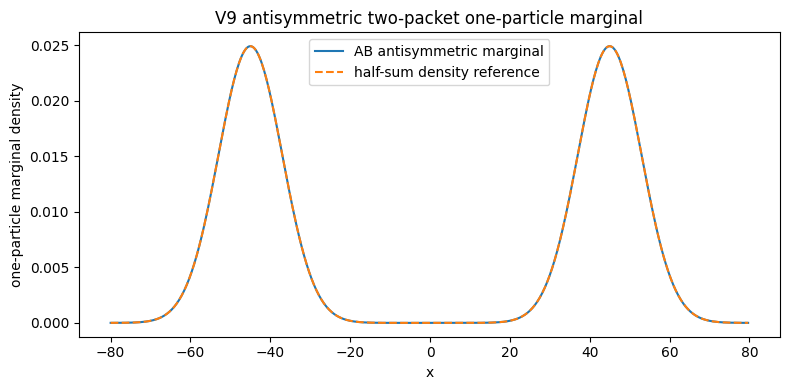

In [7]:
# ============================================================
# CELL 6 — ONE-PARTICLE MARGINAL DENSITY OF THE ANTISYMMETRIC STATE
# ============================================================

def marginal_density_from_two(Psi2):
    """
    One-particle marginal density for a two-packet antisymmetric state.

    Expected Psi2 shape:
        (x1, spin1, x2, spin2)

    We integrate/sum over:
        spin1, x2, spin2

    leaving:
        rho1(x1)

    The extra dx integrates over the second particle coordinate x2.
    """
    rho1 = np.sum(np.abs(Psi2)**2, axis=(1, 2, 3)) * dx
    return rho1.real

rho_AB_marginal = marginal_density_from_two(Psi_AB)
rho_AC_marginal = marginal_density_from_two(Psi_AC)

# Safety checks
print("rho_AB_marginal shape:", rho_AB_marginal.shape)
print("rho_AC_marginal shape:", rho_AC_marginal.shape)
print("x shape:", x.shape)

pd.DataFrame({
    "x": np.asarray(x).ravel(),
    "rho_A": np.asarray(rhoA).ravel(),
    "rho_B": np.asarray(rhoB).ravel(),
    "rho_C": np.asarray(rhoC).ravel(),
    "rho_AB_one_particle_marginal": np.asarray(rho_AB_marginal).ravel(),
    "rho_AC_one_particle_marginal": np.asarray(rho_AC_marginal).ravel()
}).to_csv(OUT / "two_packet_marginal_densities_v9.csv", index=False)

print("Integral marginal AB:", float(np.sum(rho_AB_marginal) * dx))
print("Integral marginal AC:", float(np.sum(rho_AC_marginal) * dx))

plt.figure(figsize=(8, 4))
plt.plot(x, rho_AB_marginal, label="AB antisymmetric marginal")
plt.plot(x, 0.5 * (rhoA + rhoB), linestyle="--", label="half-sum density reference")
plt.xlabel("x")
plt.ylabel("one-particle marginal density")
plt.title("V9 antisymmetric two-packet one-particle marginal")
plt.legend()
savefig("fig_v9_antisymmetric_marginal_density.png")

,separation,overlap_abs,overlap_sq,wedge_raw_norm_sq,exclusion_penalty_proxy
0,0.0,1.000000,1.000000,0.000000,inf
1,5.0,0.952345,0.906961,0.093039,10.748137
2,10.0,0.822578,0.676634,0.323366,3.092470
3,15.0,0.644389,0.415237,0.584763,1.710094
4,20.0,0.457833,0.209611,0.790389,1.265200
5,25.0,0.295023,0.087038,0.912962,1.095336
6,30.0,0.172422,0.029729,0.970271,1.030640
7,35.0,0.091394,0.008353,0.991647,1.008423


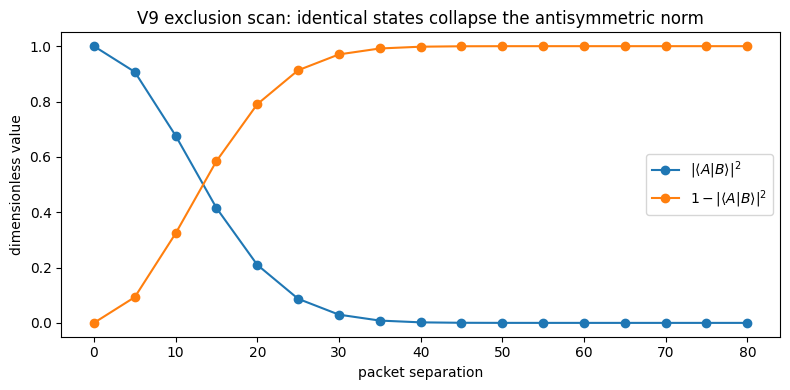

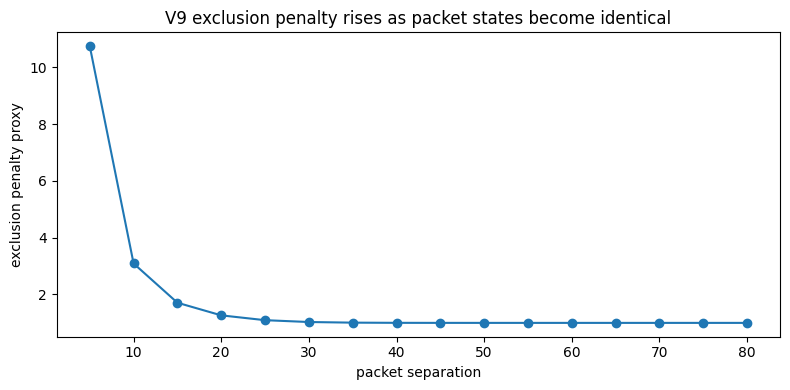

In [8]:
# ============================================================
# CELL 7 — OVERLAP / EXCLUSION SCAN
# ============================================================

sep_values = np.linspace(0, 80, 17)
scan_rows = []
for sep in sep_values:
    left = build_positive_packet(x0=-sep/2, branch=0)
    right = build_positive_packet(x0= sep/2, branch=0)
    S = inner_single(left, right)
    raw = wedge_norm_sq(left, right)
    penalty = np.inf if raw <= 1e-15 else 1.0/raw
    scan_rows.append({
        "separation": sep,
        "overlap_abs": abs(S),
        "overlap_sq": abs(S)**2,
        "wedge_raw_norm_sq": raw,
        "exclusion_penalty_proxy": penalty
    })

scan_df = pd.DataFrame(scan_rows)
scan_df.to_csv(OUT/"overlap_exclusion_scan_v9.csv", index=False)
display(scan_df.head(8))

plt.figure(figsize=(8,4))
plt.plot(scan_df["separation"], scan_df["overlap_sq"], marker="o", label=r"$|\langle A|B\rangle|^2$")
plt.plot(scan_df["separation"], scan_df["wedge_raw_norm_sq"], marker="o", label=r"$1-|\langle A|B\rangle|^2$")
plt.xlabel("packet separation")
plt.ylabel("dimensionless value")
plt.title("V9 exclusion scan: identical states collapse the antisymmetric norm")
plt.legend()
savefig("fig_v9_overlap_exclusion_scan.png")

plt.figure(figsize=(8,4))
finite = scan_df[np.isfinite(scan_df["exclusion_penalty_proxy"])]
plt.plot(finite["separation"], finite["exclusion_penalty_proxy"], marker="o")
plt.xlabel("packet separation")
plt.ylabel("exclusion penalty proxy")
plt.title("V9 exclusion penalty rises as packet states become identical")
savefig("fig_v9_exclusion_penalty_proxy.png")

  t  norm_A  norm_B       x_A        x_B  overlap_abs  wedge_raw_norm_sq  two_norm  exchange_plus_residual  positive_branch_A  negative_branch_A  positive_branch_B  negative_branch_B  single_norm_error_max  two_norm_error
0.0     1.0     1.0 44.998937 -44.999112      0.00007                1.0       1.0                     0.0                1.0       9.587571e-32                1.0       9.735693e-32           4.440892e-16    2.220446e-16
1.0     1.0     1.0 45.973403 -44.024252      0.00007                1.0       1.0                     0.0                1.0       7.996843e-32                1.0       7.848111e-32           4.440892e-16    3.330669e-16
2.0     1.0     1.0 46.947342 -43.049229      0.00007                1.0       1.0                     0.0                1.0       6.979548e-32                1.0       6.712055e-32           2.220446e-16    6.661338e-16
3.0     1.0     1.0 47.920431 -42.074110      0.00007                1.0       1.0                     0.0      

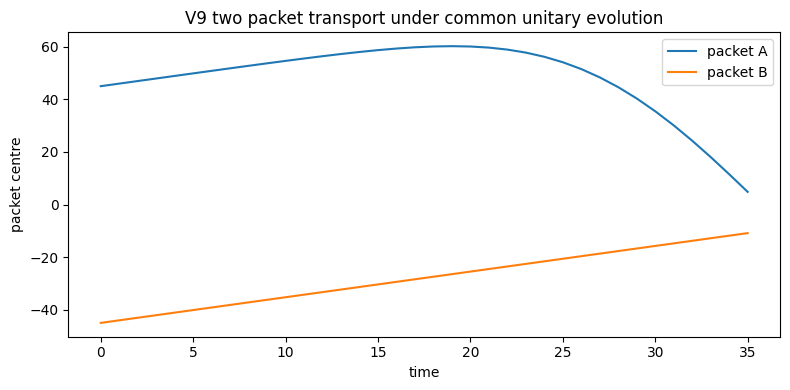

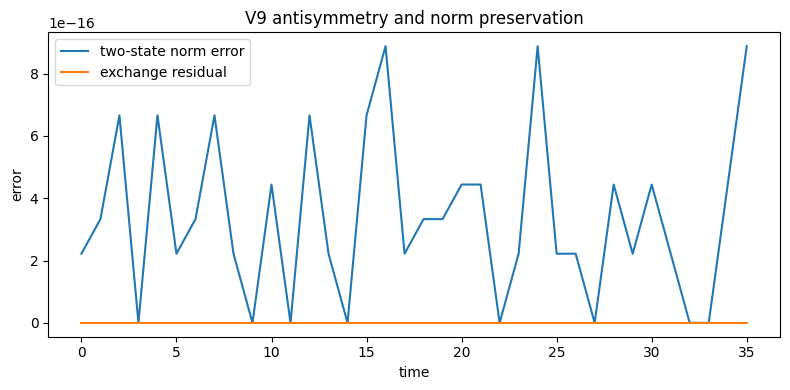

In [9]:
# ============================================================
# CELL 8 — UNITARY PROPAGATION PRESERVES ANTISYMMETRY
# ============================================================

def evolve_exact(psi, t, chi=1.0, A0=0.0):
    psik = np.fft.fft(psi, axis=0)
    outk = np.zeros_like(psik)
    for i,kval in enumerate(k):
        vals, vecs = np.linalg.eigh(Hk(kval, chi=chi, A0=A0))
        coeff = vecs.conj().T @ psik[i]
        outk[i] = vecs @ (np.exp(-1j*vals*t) * coeff)
    return np.fft.ifft(outk, axis=0)

times = np.linspace(0, 35, 36)
dyn_rows = []
for tt in times:
    A_t = evolve_exact(phi_A, tt)
    B_t = evolve_exact(phi_B, tt)
    S_t = inner_single(A_t, B_t)
    Psi_t, raw_t = antisym_state(A_t, B_t)
    wpA, wnA = project_branch_weights(A_t)
    wpB, wnB = project_branch_weights(B_t)
    exch = np.sqrt(norm_two(exchange_two(Psi_t) + Psi_t))
    dyn_rows.append({
        "t": tt,
        "norm_A": norm_psi(A_t),
        "norm_B": norm_psi(B_t),
        "x_A": expectation_x(A_t),
        "x_B": expectation_x(B_t),
        "overlap_abs": abs(S_t),
        "wedge_raw_norm_sq": raw_t,
        "two_norm": norm_two(Psi_t),
        "exchange_plus_residual": exch,
        "positive_branch_A": wpA,
        "negative_branch_A": wnA,
        "positive_branch_B": wpB,
        "negative_branch_B": wnB
    })

dyn = pd.DataFrame(dyn_rows)
dyn["single_norm_error_max"] = np.maximum(np.abs(dyn["norm_A"]-1), np.abs(dyn["norm_B"]-1))
dyn["two_norm_error"] = np.abs(dyn["two_norm"]-1)
dyn.to_csv(OUT/"antisymmetric_propagation_history_v9.csv", index=False)

print(dyn.head().to_string(index=False))
print("\nMax single norm error:", dyn["single_norm_error_max"].max())
print("Max two-state norm error:", dyn["two_norm_error"].max())
print("Max exchange residual:", dyn["exchange_plus_residual"].max())
print("Max overlap drift:", np.max(np.abs(dyn["overlap_abs"] - dyn["overlap_abs"].iloc[0])))

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["x_A"], label="packet A")
plt.plot(dyn["t"], dyn["x_B"], label="packet B")
plt.xlabel("time")
plt.ylabel("packet centre")
plt.title("V9 two packet transport under common unitary evolution")
plt.legend()
savefig("fig_v9_two_packet_transport.png")

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["two_norm_error"], label="two-state norm error")
plt.plot(dyn["t"], dyn["exchange_plus_residual"], label="exchange residual")
plt.xlabel("time")
plt.ylabel("error")
plt.title("V9 antisymmetry and norm preservation")
plt.legend()
savefig("fig_v9_antisymmetry_preservation.png")

Running chi= 1.0
Running chi= 0.95
Running chi= 0.8
Running chi= 0.5
Running chi= 0.2
 chi  sqrt_chi  t_final  norm_A  norm_B       x_A        x_B   width_A  width_B  overlap_abs  wedge_raw_norm_sq  two_norm  exchange_plus_residual  branch_weight_error_A  branch_weight_error_B  negative_branch_A  negative_branch_B  max_single_norm_error  two_norm_error  packet_separation_final
1.00  1.000000     25.0     1.0     1.0 54.098295 -20.618872 42.907284 8.001106      0.00007                1.0       1.0                     0.0           1.110223e-16           1.110223e-16       7.911301e-32       7.187561e-32           2.220446e-16    2.220446e-16                74.717167
0.95  0.974679     25.0     1.0     1.0 55.532292 -21.266998 40.150888 8.002481      0.00007                1.0       1.0                     0.0           2.220446e-16           2.220446e-16       7.818783e-06       7.818783e-06           4.440892e-16    2.220446e-16                76.799290
0.80  0.894427     25.0     1.0 

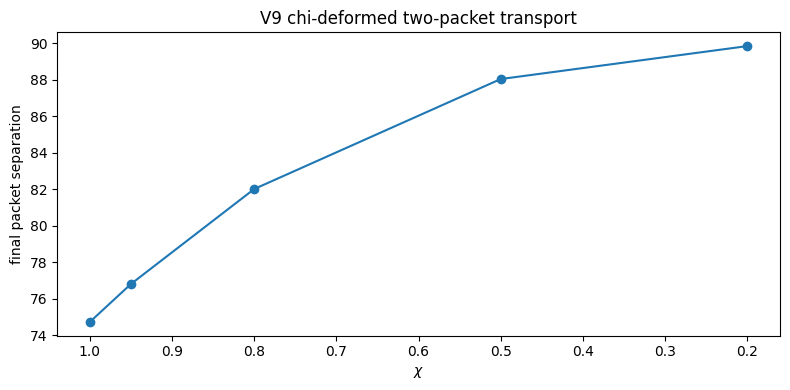

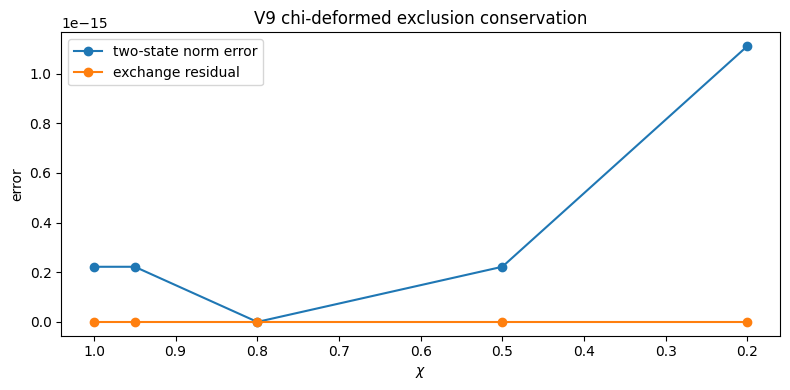

In [10]:
# ============================================================
# CELL 9 — CHI-DEFORMED EXCLUSION PRESERVATION SCAN
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
t_final = 25.0
chi_rows = []

for chi in chi_values:
    print("Running chi=", chi)
    A_t = evolve_exact(phi_A, t_final, chi=chi)
    B_t = evolve_exact(phi_B, t_final, chi=chi)
    S_t = inner_single(A_t, B_t)
    Psi_t, raw_t = antisym_state(A_t, B_t)
    wpA, wnA = project_branch_weights(A_t, chi=chi)
    wpB, wnB = project_branch_weights(B_t, chi=chi)
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "t_final": t_final,
        "norm_A": norm_psi(A_t),
        "norm_B": norm_psi(B_t),
        "x_A": expectation_x(A_t),
        "x_B": expectation_x(B_t),
        "width_A": width_x(A_t),
        "width_B": width_x(B_t),
        "overlap_abs": abs(S_t),
        "wedge_raw_norm_sq": raw_t,
        "two_norm": norm_two(Psi_t),
        "exchange_plus_residual": np.sqrt(norm_two(exchange_two(Psi_t) + Psi_t)),
        "branch_weight_error_A": abs((wpA+wnA)-1),
        "branch_weight_error_B": abs((wpB+wnB)-1),
        "negative_branch_A": wnA,
        "negative_branch_B": wnB
    })

chi_df = pd.DataFrame(chi_rows)
chi_df["max_single_norm_error"] = np.maximum(np.abs(chi_df["norm_A"]-1), np.abs(chi_df["norm_B"]-1))
chi_df["two_norm_error"] = np.abs(chi_df["two_norm"]-1)
chi_df["packet_separation_final"] = np.abs(chi_df["x_B"] - chi_df["x_A"])
chi_df.to_csv(OUT/"chi_deformed_exclusion_scan_v9.csv", index=False)

print(chi_df.to_string(index=False))
print("\nMax chi single norm error:", chi_df["max_single_norm_error"].max())
print("Max chi two norm error:", chi_df["two_norm_error"].max())
print("Max chi exchange residual:", chi_df["exchange_plus_residual"].max())
print("Chi transport separation range:", chi_df["packet_separation_final"].max()-chi_df["packet_separation_final"].min())

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["packet_separation_final"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel(r"$\chi$")
plt.ylabel("final packet separation")
plt.title("V9 chi-deformed two-packet transport")
savefig("fig_v9_chi_deformed_transport.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["two_norm_error"], marker="o", label="two-state norm error")
plt.plot(chi_df["chi"], chi_df["exchange_plus_residual"], marker="o", label="exchange residual")
plt.gca().invert_xaxis()
plt.xlabel(r"$\chi$")
plt.ylabel("error")
plt.title("V9 chi-deformed exclusion conservation")
plt.legend()
savefig("fig_v9_chi_exclusion_conservation.png")

In [11]:
# ============================================================
# CELL 10 — FINAL V9 VERDICT TABLE
# ============================================================

q_error = abs(float(packet["q_eff"]) + 1.0)
N_plus_error = abs(float(packet["N_plus"]) - 0.0)
N_zero_error = abs(float(packet["N_zero"]) - 1.0)
N_minus_error = abs(float(packet["N_minus"]) - 3.0)
alpha_beta_max_error = float(alpha_df["error"].max())

identical_forbidden_error = float(raw_AA)
AB_exchange_error = float(exchange_residual_AB)
AC_exchange_error = float(exchange_residual_AC)
AB_norm_error = abs(float(norm_two(Psi_AB))-1.0)
AC_norm_error = abs(float(norm_two(Psi_AC))-1.0)
overlap_AB_abs = abs(S_AB)
overlap_AC_abs = abs(S_AC)

max_single_norm_error = float(dyn["single_norm_error_max"].max())
max_two_norm_error = float(dyn["two_norm_error"].max())
max_exchange_residual = float(dyn["exchange_plus_residual"].max())
max_overlap_drift = float(np.max(np.abs(dyn["overlap_abs"] - dyn["overlap_abs"].iloc[0])))

max_chi_single_norm_error = float(chi_df["max_single_norm_error"].max())
max_chi_two_norm_error = float(chi_df["two_norm_error"].max())
max_chi_exchange_residual = float(chi_df["exchange_plus_residual"].max())
chi_transport_range = float(chi_df["packet_separation_final"].max() - chi_df["packet_separation_final"].min())

near_identical = scan_df.iloc[0]
far_separated = scan_df.iloc[-1]
exclusion_rises = float(far_separated["wedge_raw_norm_sq"] - near_identical["wedge_raw_norm_sq"])

verdict_rows = [
    ("packet remains q=-1 scaffold", q_error, q_error < 2e-3),
    ("packet N_plus near 0", N_plus_error, N_plus_error < 2e-3),
    ("packet N_zero near 1", N_zero_error, N_zero_error < 2e-3),
    ("packet N_minus near 3", N_minus_error, N_minus_error < 2e-3),
    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),
    ("identical single-particle state antisymmetrizes to zero", identical_forbidden_error, identical_forbidden_error < 1e-12),
    ("separated same-internal states allowed", AB_norm_error, AB_norm_error < 1e-12),
    ("orthogonal internal states allowed at same location", AC_norm_error, AC_norm_error < 1e-12),
    ("AB exchange gives minus sign", AB_exchange_error, AB_exchange_error < 1e-12),
    ("AC exchange gives minus sign", AC_exchange_error, AC_exchange_error < 1e-12),
    ("AB single-state overlap small", overlap_AB_abs, overlap_AB_abs < 1e-3),
    ("AC internal-state overlap near zero", overlap_AC_abs, overlap_AC_abs < 1e-12),
    ("exclusion norm opens with packet separation", exclusion_rises, exclusion_rises > 0.99),
    ("unitary single-particle norms preserved", max_single_norm_error, max_single_norm_error < 1e-12),
    ("unitary two-particle norm preserved", max_two_norm_error, max_two_norm_error < 1e-12),
    ("unitary exchange antisymmetry preserved", max_exchange_residual, max_exchange_residual < 1e-12),
    ("single-particle overlap conserved under common unitary", max_overlap_drift, max_overlap_drift < 1e-12),
    ("chi-deformed single-particle norms preserved", max_chi_single_norm_error, max_chi_single_norm_error < 1e-12),
    ("chi-deformed two-particle norm preserved", max_chi_two_norm_error, max_chi_two_norm_error < 1e-12),
    ("chi-deformed exchange antisymmetry preserved", max_chi_exchange_residual, max_chi_exchange_residual < 1e-12),
    ("chi changes two-packet transport", chi_transport_range, chi_transport_range > 1.0),
]

verdict = pd.DataFrame(verdict_rows, columns=["criterion","value","pass"])
verdict.to_csv(OUT/"final_exclusion_antisymmetry_v9_verdict.csv", index=False)
print(verdict.to_string(index=False))

final_label = (
    "PASS: fermion-like antisymmetry and exclusion bridge for ECSM electron-like packets"
    if verdict["pass"].all()
    else "CONDITIONAL/FAIL: antisymmetry/exclusion criteria not all satisfied"
)

summary = {
    "final_label": final_label,
    "n_pass": int(verdict["pass"].sum()),
    "n_criteria": int(len(verdict)),
    "q_eff": float(packet["q_eff"]),
    "m_lock_dimensionless": float(m_lock),
    "identical_wedge_norm_sq": float(raw_AA),
    "AB_overlap_abs": float(overlap_AB_abs),
    "AC_overlap_abs": float(overlap_AC_abs),
    "AB_exchange_residual": float(AB_exchange_error),
    "AC_exchange_residual": float(AC_exchange_error),
    "max_single_norm_error": max_single_norm_error,
    "max_two_norm_error": max_two_norm_error,
    "max_exchange_residual": max_exchange_residual,
    "max_overlap_drift": max_overlap_drift,
    "max_chi_single_norm_error": max_chi_single_norm_error,
    "max_chi_two_norm_error": max_chi_two_norm_error,
    "max_chi_exchange_residual": max_chi_exchange_residual,
    "chi_transport_range": chi_transport_range
}

with open(OUT/"run_summary_v9.json", "w") as f:
    json.dump(summary, f, indent=2)

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT/"output_file_manifest_v9.csv", index=False)

print("\nFinal label:", final_label)
print(json.dumps(summary, indent=2))
print("\nOutput files:")
display(manifest)

                                              criterion        value  pass
                           packet remains q=-1 scaffold 6.964280e-04  True
                                   packet N_plus near 0 9.716379e-04  True
                                   packet N_zero near 1 1.460081e-04  True
                                  packet N_minus near 3 1.117646e-03  True
                           alpha/beta closure inherited 0.000000e+00  True
identical single-particle state antisymmetrizes to zero 0.000000e+00  True
                 separated same-internal states allowed 4.440892e-16  True
    orthogonal internal states allowed at same location 4.440892e-16  True
                           AB exchange gives minus sign 0.000000e+00  True
                           AC exchange gives minus sign 0.000000e+00  True
                          AB single-state overlap small 6.963818e-05  True
                    AC internal-state overlap near zero 1.871333e-41  True
            exclusion nor

,file
0,alpha_beta_algebra_tests_v9.csv
1,antisymmetric_propagation_history_v9.csv
2,antisymmetry_exclusion_tests_v9.csv
3,chi_deformed_exclusion_scan_v9.csv
4,fig_v9_antisymmetric_marginal_density.png
5,fig_v9_antisymmetry_preservation.png
6,fig_v9_chi_deformed_transport.png
7,fig_v9_chi_exclusion_conservation.png
8,fig_v9_exclusion_penalty_proxy.png
9,fig_v9_overlap_exclusion_scan.png
